<a href="https://colab.research.google.com/github/hmdaalln/Final_dataset/blob/main/Final_image_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Denoising

## Project Overview :

In this notebook, we prepare the SIDD dataset and develop a DnCNN model for image denoising.

The workflow includes dataset exploration, data preprocessing, patch generation, model development, training, performance profiling, evaluation, and visualization.

The goal is to train a deep learning model that removes image noise while preserving important visual details such as edges and textures.

## Problem Statement

Image noise can reduce image quality and negatively affect many computer vision applications.

Our objective is to build a model that learns how to transform noisy images into clean images while keeping edges and textures as natural as possible.

## Project Objectives

The main objectives of this project are:

- Explore and understand the SIDD dataset.
- Prepare the dataset for training.
- Train a deep learning model for image denoising.
- Evaluate the model using MSE, PSNR and SSIM.
- Compare the model performance and visualize the results.

## Dataset Description - will update later

This project uses the Smartphone Image Denoising Dataset (SIDD).

The dataset contains pairs of noisy and clean images captured using different smartphones under various lighting conditions. It is specifically designed for image denoising tasks.

## Workflow

1. Import Libraries
2. Explore the Dataset
3. Data Preprocessing
4. Create DataLoaders
5. Build the DnCNN Model
6. Configure the Training Process
7. Profile the Training Pipeline
8. Train and Validate the Model
9. Select the Best Model
10. Evaluate the Model using MSE, PSNR, and SSIM
11. Visualize Denoising Results
12. Save the Final Model

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries

In [81]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy
import time
import pandas as pd
import random

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [2]:
#  Set a fixed random seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print ("Random seed:", SEED)

Random seed: 42


**Why this code?**

A fixed random seed improves the reproducibility of the experiment.

The project contains random operations such as model initialization, training patch selection, and data augmentation. Using the same seed helps make repeated experiments more consistent.

**What did we notice?**

The random seed was set to 42 and will be used throughout the experiment.

## 2. Dataset Exploration

In this section, we explore the SIDD dataset to understand its structure and examine a sample pair of noisy and clean images before training the model.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
 # new
#Import libraries and define paths
dataset_root = "/content/drive/MyDrive/cap/ISOCELL_GN1"

train_original = os.path.join(dataset_root, "training_set", "original")
train_denoised = os.path.join(dataset_root, "training_set", "denoised")

test_original = os.path.join(dataset_root, "test_set", "original")
test_denoised = os.path.join(dataset_root, "test_set", "denoised")



In [5]:
print("Training original exists:", os.path.exists(train_original))
print("Training denoised exists:", os.path.exists(train_denoised))
print("Testing original exists:", os.path.exists(test_original))
print("Testing denoised exists:", os.path.exists(test_denoised))

Training original exists: True
Training denoised exists: True
Testing original exists: True
Testing denoised exists: True


In [6]:
# Get image filenames
train_original_files = sorted(os.listdir(train_original))
train_denoised_files = sorted(os.listdir(train_denoised))

test_original_files = sorted(os.listdir(test_original))
test_denoised_files = sorted(os.listdir(test_denoised))

In [7]:
# Check the number of images
print("Training original:", len(train_original_files))
print("Training denoised:", len(train_denoised_files))
print("Testing original:", len(test_original_files))
print("Testing denoised:", len(test_denoised_files))

# Check that the filenames match
print("Training files match:", train_original_files == train_denoised_files)
print("Testing files match:", test_original_files == test_denoised_files)

Training original: 812
Training denoised: 812
Testing original: 87
Testing denoised: 87
Training files match: True
Testing files match: True


##### Check Image Pairs

We checked that each original image has a matching denoised image with the same filename.

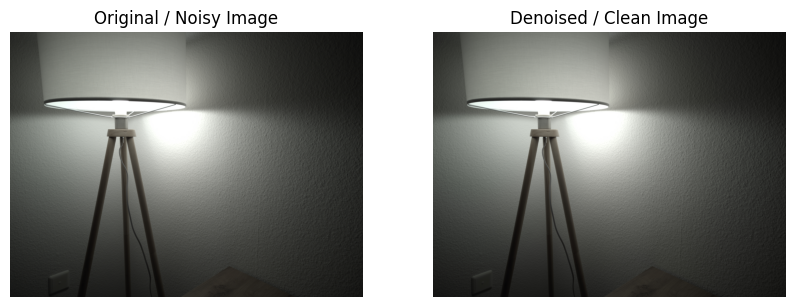

Image name: 0.jpg


In [8]:
from PIL import Image # new
import matplotlib.pyplot as plt
import os

# Get the first image name
image_name = sorted(os.listdir(train_original))[0]

noisy_path = os.path.join(train_original, image_name)
clean_path = os.path.join(train_denoised, image_name)

# Read the images
noisy_image = Image.open(noisy_path)
clean_image = Image.open(clean_path)

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy_image)
plt.title("Original / Noisy Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_image)
plt.title("Denoised / Clean Image")
plt.axis("off")

plt.show()

print("Image name:", image_name)


### Observation


The new dataset is already divided into a training set and a test set.

Each input image in the `original` folder is paired with an image that has the same filename in the `denoised` folder.

The training set contains 812 image pairs, while the test set contains 87 image pairs. The provided test set will remain unchanged for the final evaluation.

## 3. Data Preprocessing

In this section, we prepare the image pairs for training.

The training images are split into training and validation sets. The provided test set is kept unchanged for final evaluation.

##3.1. Split the Dataset

In [9]:
from sklearn.model_selection import train_test_split # new

train_files, val_files = train_test_split(
    train_original_files,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

test_files = test_original_files

print("Training images:", len(train_files))
print("Validation images:", len(val_files))
print("Testing images:", len(test_files))

Training images: 730
Validation images: 82
Testing images: 87


**Why this code?**

We split the 812 training images into training and validation sets. We kept the 87 test images unchanged.

**What did we notice?**

The dataset was divided into:

- 730 training images
- 82 validation images
- 87 testing images

## 3.2. Precompute the Image Pair Paths

In [10]:
def create_pairs(files, input_folder, clean_folder):
    pairs = []

    for name in files:
        pairs.append({
            "noisy_path": os.path.join(input_folder, name),
            "clean_path": os.path.join(clean_folder, name)
        })

    return pairs

**Why this code?**

This function connects each input image with the clean image that has the same filename.

## 3.3. Create the File Path Lists

In [11]:
# Create the training pairs
train_pairs = create_pairs(
    train_files,
    train_original,
    train_denoised
)

# Create the validation pairs
val_pairs = create_pairs(
    val_files,
    train_original,
    train_denoised
)

# Create the testing pairs
test_pairs = create_pairs(
    test_files,
    test_original,
    test_denoised
)

# Remove the corrupted test image pair
test_pairs = [
    pair for pair in test_pairs
    if os.path.basename(pair["clean_path"]) != "735.png"
]

# Display the number of pairs
print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Testing pairs:", len(test_pairs))

Training pairs: 730
Validation pairs: 82
Testing pairs: 86


**What did we notice?**

We created 730 training pairs, 82 validation pairs, and 87 testing pairs.

**What did we notice?**

The final path lists contain:

- **730 training pairs**
- **82 validation pairs**
- **87 testing pairs**


## 3.4 Verify Noisy-Clean Image Pair Matching

In [12]:
# Display the first five pairs
for pair in train_pairs[:5]:
    print(
        os.path.basename(pair["noisy_path"]),
        "->",
        os.path.basename(pair["clean_path"])
    )

622.jpg -> 622.jpg
1073.jpg -> 1073.jpg
11.jpg -> 11.jpg
650.jpg -> 650.jpg
68.jpg -> 68.jpg


**Why this code?**

We displayed some filenames to confirm that each input image is matched with the correct clean image.

## 3.5. Generate the Image Patches Once

In [13]:
def create_patches(
    image_pairs,
    patch_size,
    patches_per_image,
    training=True
):

    # Lists to store the patches
    noisy_patches = []
    clean_patches = []

    # Go through each image pair
    for pair in tqdm(image_pairs):

        # Open the noisy and clean images
        noisy_image = Image.open(
            pair["noisy_path"]
        ).convert("RGB")

        clean_image = Image.open(
            pair["clean_path"]
        ).convert("RGB")

        # Get the image size
        width, height = noisy_image.size

        # Create patches from the image pair
        for patch_index in range(patches_per_image):

            if training:
                # Choose a random position for training
                i, j, h, w = transforms.RandomCrop.get_params(
                    noisy_image,
                    output_size=(patch_size, patch_size)
                )

            else:
                # Use fixed positions for validation and testing
                positions = [
                    (0, 0),
                    (0, width - patch_size),
                    (height - patch_size, 0),
                    (
                        height - patch_size,
                        width - patch_size
                    )
                ]

                i, j = positions[patch_index]
                h = patch_size
                w = patch_size

            # Crop the same location from both images
            noisy_patch = TF.crop(
                noisy_image,
                i,
                j,
                h,
                w
            )

            clean_patch = TF.crop(
                clean_image,
                i,
                j,
                h,
                w
            )

            # Convert the patches to tensors
            noisy_patch = TF.to_tensor(noisy_patch)
            clean_patch = TF.to_tensor(clean_patch)

            # Save the patches
            noisy_patches.append(noisy_patch)
            clean_patches.append(clean_patch)

    # Combine all patches into tensors
    noisy_patches = torch.stack(noisy_patches)
    clean_patches = torch.stack(clean_patches)

    return noisy_patches, clean_patches

**Why this code?**

This function creates smaller patches from the input and clean images. The same location is cropped from both images to keep them correctly matched.

Training patches are selected randomly to use different image regions. Validation and testing patches use fixed locations to keep the evaluation consistent.

**What did we notice?**

The patches are converted into tensors with pixel values between 0 and 1. No data augmentation is applied.

## 3.6. Generate Training, Validation, and Test Patches

In [14]:
# Generate training patches
train_noisy, train_clean = create_patches(
    train_pairs,
    patch_size=128,
    patches_per_image=8, # change from 4 --> 8
    training=True
)

# Generate validation patches
val_noisy, val_clean = create_patches(
    val_pairs,
    patch_size=128,
    patches_per_image=4,
    training=False
)

# Generate testing patches
test_noisy, test_clean = create_patches(
    test_pairs,
    patch_size=128,
    patches_per_image=4,
    training=False
)

print("Training noisy patches:", train_noisy.shape)
print("Training clean patches:", train_clean.shape)

print("Validation noisy patches:", val_noisy.shape)
print("Validation clean patches:", val_clean.shape)

print("Testing noisy patches:", test_noisy.shape)
print("Testing clean patches:", test_clean.shape)

  0%|          | 0/730 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

Training noisy patches: torch.Size([5840, 3, 128, 128])
Training clean patches: torch.Size([5840, 3, 128, 128])
Validation noisy patches: torch.Size([328, 3, 128, 128])
Validation clean patches: torch.Size([328, 3, 128, 128])
Testing noisy patches: torch.Size([344, 3, 128, 128])
Testing clean patches: torch.Size([344, 3, 128, 128])


**Why this code?**

This code creates four patches of size 128 × 128 from each image pair.

**What did we notice?**

We created:

- 2920 training patches
- 328 validation patches
- 344 testing patches

One corrupted test image pair was excluded.



## 3.7. Create the Patch Dataset Class

In [15]:
class PatchDataset(Dataset):

    def __init__(
        self,
        noisy_patches,
        clean_patches
    ):
        # Store the precomputed patches
        self.noisy_patches = noisy_patches
        self.clean_patches = clean_patches

    def __len__(self):

        # Return the total number of patches
        return len(self.noisy_patches)

    def __getitem__(self, index):

        # Get one noisy patch
        noisy = self.noisy_patches[index]

        # Get the matching clean patch
        clean = self.clean_patches[index]

        # Calculate the true residual noise
        noise_target = noisy - clean

        # Return the training sample
        return {
            "noisy": noisy,
            "clean": clean,
            "noise_target": noise_target
        }

**Why this code?**

This class stores the patches and returns the noisy image, clean image, and noise target.

## 3.8. Create the Dataset Objects

In [16]:
# Create the training dataset
train_dataset = PatchDataset(
    train_noisy,
    train_clean
)

# Create the validation dataset
val_dataset = PatchDataset(
    val_noisy,
    val_clean
)

# Create the testing dataset
test_dataset = PatchDataset(
    test_noisy,
    test_clean
)

# Check dataset sizes
print("Training patches:", len(train_dataset))
print("Validation patches:", len(val_dataset))
print("Testing patches:", len(test_dataset))

Training patches: 5840
Validation patches: 328
Testing patches: 344


**Why this code?**

This code creates the training, validation, and testing datasets.

## 3.9. Check One Sample

In [17]:
# Load one training sample
sample = train_dataset[0]

# Display the tensor shapes
print("Noisy shape:", sample["noisy"].shape)
print("Clean shape:", sample["clean"].shape)
print(
    "Noise target shape:",
    sample["noise_target"].shape
)

Noisy shape: torch.Size([3, 128, 128])
Clean shape: torch.Size([3, 128, 128])
Noise target shape: torch.Size([3, 128, 128])


**Observation**

The noisy, clean, and noise target patches all have the correct shape of `[3, 128, 128]`.

## 4. Create DataLoaders
In this step, we create DataLoaders for the training, validation, and testing datasets. The DataLoader loads the images in batches during training.

In [18]:
from torch.utils.data import DataLoader

# Use a larger batch for faster training
batch_size = 8 # chnage

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Testing DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Check sizes
print("Training patches:", len(train_dataset))
print("Validation patches:", len(val_dataset))
print("Testing patches:", len(test_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training patches: 5840
Validation patches: 328
Testing patches: 344
Training batches: 730
Validation batches: 41
Testing batches: 43


**Why this code?**

The DataLoaders divide the patches into batches. Training data is shuffled, while validation and testing data remain in a fixed order.

We used a batch size of 16 to make training faster on the GPU.

**What did we notice?**

The datasets contain 2920 training patches, 328 validation patches, and 344 testing patches.

In [19]:
# Check one batch

# Load one training batch
batch = next(iter(train_loader))

# Get the three tensors
noisy_batch = batch["noisy"]
clean_batch = batch["clean"]
noise_target_batch = batch[
    "noise_target"
]

# Display the batch shapes
print(
    "Noisy batch:",
    noisy_batch.shape
)

print(
    "Clean batch:",
    clean_batch.shape
)

print(
    "Noise target:",
    noise_target_batch.shape
)

Noisy batch: torch.Size([8, 3, 128, 128])
Clean batch: torch.Size([8, 3, 128, 128])
Noise target: torch.Size([8, 3, 128, 128])


**Why this code?**

This step verifies that the DataLoader returns correctly structured batches before the model is trained.

**What did we notice?**

Each batch has the shape **[16, 3, 128, 128]** for the noisy input, clean target, and noise residual, confirming compatibility with DnCNN.

## 5. Build and Train the DnCNN Model


---

In this section, we build the DnCNN model and prepare it for training.

**DnCNN** uses residual learning. Instead of predicting the clean image directly, the model predicts the noise contained in the image.

The true noise residual is calculated as:

$$
\text{Noise Target}
=
\text{Noisy Image}
-
\text{Clean Image}
$$

The denoised image is calculated as:

$$
\text{Denoised Image}
=
\text{Noisy Image}
-
\text{Predicted Noise}
$$

This approach allows the model to learn the noise present in the image rather than predicting the clean image directly. After the model predicts the noise residual, the denoised image is obtained by subtracting the predicted noise from the noisy input.


## 5.1. Build the DnCNN Architecture

In [20]:
class DnCNN(nn.Module):

    def __init__(
        self,
        image_channels=3,
        depth=17,
        features=128
    ):
        # Initialize the parent PyTorch neural-network class
        super().__init__()

        # Create an empty list that will store all model layers
        layers = []

        # First convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=image_channels,
                out_channels=features,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        # Apply the ReLU activation function
        layers.append(nn.ReLU(inplace=True))

        # Middle convolution layers
        for _ in range(depth - 2):

          #Extract deeper image and noise features
            layers.append(
                nn.Conv2d(
                    in_channels=features,
                    out_channels=features,
                    kernel_size=3,
                    padding=1,
                    bias=False
                )
            )

            # Normalize the feature maps to improve training stability
            layers.append(nn.BatchNorm2d(features))

            # Add non-linearity
            layers.append(nn.ReLU(inplace=True))

        # Final convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=features,
                out_channels=image_channels,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        # Combine all layers into one sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):

        # Pass the noisy image through the model
        predicted_noise = self.model(x)

        # Return the predicted noise residual
        return predicted_noise

**Why this code?**

This code creates the DnCNN model. The model takes a noisy RGB image and predicts the noise inside it.

The first layer extracts image features, the middle layers learn the noise patterns, and the final layer predicts the noise.

**Why do we use residual learning?**

The model learns the noise instead of learning the full clean image. The clean image can then be obtained by subtracting the predicted noise from the noisy image.

**Model settings**

- `image_channels=3` because the images are RGB.
- `depth=17` means the model contains 17 convolutional layers.
- `features=64` means the hidden layers use 64 feature maps.
- `kernel_size=3` applies a 3 × 3 filter.
- `padding=1` keeps the image size unchanged.

**What did we notice?**

The model input and output both have three channels and the same image size.

## 5.2. Select the device



In [21]:
# Select the GPU when available; otherwise use the CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Display the selected device
print("Device:", device)

Device: cuda


**Why this code?**

This code checks whether a GPU is available.

A GPU can train the deep learning model faster than a CPU.

**Step explanation**

- torch.cuda.is_available() checks whether CUDA is available.
- If CUDA is available, the device is set to cuda.
- Otherwise, the device is set to cpu.

**What did we notice?**

The output was:

**Device: cuda**

This means the notebook is using a GPU runtime.

The model and image batches must be moved to the same device.

## 5.3. Test the Model with  a Random Tensor

In [22]:
# Create a temporary DnCNN model for architecture testing
test_model = DnCNN()

# Create a random tensor that represents a batch of images
x = torch.randn(
    4,     # Batch size
    3,      # RGB channels
    128,     # Image height
    128      # Image width
)

# Pass the random batch through the model
y = test_model(x)

# Display the input and output shapes
print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([4, 3, 128, 128])
Output shape: torch.Size([4, 3, 128, 128])


**Why this code?**

This code tests the model using a randomly generated tensor before using real images.

It confirms that the model architecture does not contain channel or dimension errors.

**Step explanation**

- 4 is the number of image patches processed together.
- 3 represents the RGB channels.
- 128 × 128 is the patch height and width.
- The random tensor is passed through DnCNN to test the architecture.
- The input and output shapes are printed.

**What did we notice?**

The input and output shapes are both:

**torch.Size([4, 3, 128, 128])**

This confirms that DnCNN predicts a three-channel noise residual with the same spatial dimensions as the input.

## 5.4. Create the DnCNN Model


In [23]:
# Create the DnCNN model
model = DnCNN(
    image_channels=3,
    depth=17,
    features=128
)

# Move the model to the selected device
model = model.to(device)

# Display the complete model architecture
print(model)

DnCNN(
  (model): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(128, 128, kernel_s

**Why this code?**

This cell creates the DnCNN model and moves it to the GPU.

**Model settings**

- image_channels=3 because the images are RGB.
- depth=17 means the model has 17 convolutional layers.
- features=128 means the hidden layers use 128 feature maps.

**What did we notice?**

The first layer converts the RGB input into 128 feature maps. The middle layers process these features, and the final layer predicts three channels of noise.

## 5.5. Count the Model Parameters

In [24]:
# Count all parameters in the model
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

# Count only the parameters that will be updated during training
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Display the parameter counts
print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 2222723
Trainable parameters: 2222723


**Why this code?**

This code counts the model parameters to show the size of DnCNN.

**What did we notice?**

The model contains 2222723 parameters, and all of them will be updated during training.

## 5.6. Test the Forward Pass

In [25]:
# Load one batch from the training DataLoader
batch = next(iter(train_loader))

# Get the noisy-image batch
noisy_batch = batch["noisy"]

# Move the batch to the selected device
noisy_batch = noisy_batch.to(device)

# Disable gradient calculations because this is only a test
with torch.no_grad():

    # Predict the noise residual
    predicted_noise = model(noisy_batch)

# Display the input and output shapes
print("Input shape:", noisy_batch.shape)
print("Predicted noise shape:", predicted_noise.shape)

Input shape: torch.Size([8, 3, 128, 128])
Predicted noise shape: torch.Size([8, 3, 128, 128])


**Why this code?**

This code checks that DnCNN can process one real batch from the DataLoader.

**What did we notice?**

The input and predicted noise have the same shape: `[16, 3, 128, 128]`. Therefore, the data and model are compatible.

## Training Setup and Training Loop


---


## 5.7. Define the Training Configuration

In [42]:
# Training settings - new
CONFIG = {
    "learning_rate": 0.001,
    "epochs": 50,
    "early_stopping_patience": 10
}

**Why this code?**

This cell stores the main training settings.

**What did we notice?**

The model uses a learning rate of `0.0001` and can train for a maximum of 50 epochs. Early stopping will stop training if the validation loss does not improve for 10 consecutive epochs.

## 5.8. Create Output Folders

In [43]:
# Main folder for the new experiment - new
OUTPUT_ROOT = (
    "/content/drive/MyDrive/cap/results"
    "ISOCELL_GN1_Results"
)

CHECKPOINT_ROOT = os.path.join(OUTPUT_ROOT, "checkpoints")
METADATA_ROOT = os.path.join(OUTPUT_ROOT, "metadata")
RESULTS_ROOT = os.path.join(OUTPUT_ROOT, "results")

os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(METADATA_ROOT, exist_ok=True)
os.makedirs(RESULTS_ROOT, exist_ok=True)

print("Checkpoint folder:", CHECKPOINT_ROOT)
print("Metadata folder:", METADATA_ROOT)
print("Results folder:", RESULTS_ROOT)


Checkpoint folder: /content/drive/MyDrive/cap/ISOCELL_GN1_Results/checkpoints
Metadata folder: /content/drive/MyDrive/cap/ISOCELL_GN1_Results/metadata
Results folder: /content/drive/MyDrive/cap/ISOCELL_GN1_Results/results


**Why this code?**

This code creates separate folders in Google Drive for saving the new model, training information, and evaluation results.

## 5.9. Define the Loss Function

In [28]:
criterion = nn.MSELoss()

**Why this code?**

MSE loss measures the difference between the predicted noise and the true noise. A lower value means that the noise prediction is more accurate.

## 5.10. Define the Optimizer

In [44]:
optimizer = Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

**Why this code?**

Adam updates the model parameters during training using the learning rate defined in `CONFIG`.

## 5.11. Define the Learning Rate Scheduler

In [45]:
# Reduce the learning rate when validation loss stops improving
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

**Why this code?**

This scheduler reduces the learning rate when the validation loss stops improving. This helps the model make smaller updates during later epochs.

## 5.12. Enable Mixed - Precision Training

In [46]:
# Create the gradient scaler for mixed-precision training
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

**Why this code?**

Mixed precision can:

- reduce GPU memory usage,
- speed up convolution operations,
- allow a larger batch size.

**What did we notice?**

The scaler is enabled only when a CUDA GPU is available.

## 5.13. Define the one Epoch Function

In [47]:
def run_epoch(model, loader, training):

    # Use training mode or evaluation mode
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    # Process every batch
    for batch in tqdm(loader, leave=False):

        # Move the data to the GPU or CPU
        noisy = batch["noisy"].to(
            device,
            non_blocking=True
        )

        target_noise = batch["noise_target"].to(
            device,
            non_blocking=True
        )

        # Clear old gradients during training
        if training:
            optimizer.zero_grad(set_to_none=True)

        # Enable gradients only during training
        with torch.set_grad_enabled(training):

            # Use mixed precision only with CUDA
            with torch.amp.autocast(
                device_type=device.type,
                enabled=(device.type == "cuda")
            ):

                # Predict the noise
                predicted_noise = model(noisy)

                # Compare predicted noise with true noise
                loss = criterion(
                    predicted_noise,
                    target_noise
                )

            # Update the model only during training
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        # Add this batch's loss
        batch_size = noisy.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    # Return the average loss
    return total_loss / total_samples

**Why this code?**

This function runs one full training or validation epoch. During training, it calculates the loss and updates the model. During validation, it only measures the loss without changing the model.

Mixed precision is used when a CUDA GPU is available to reduce memory use and improve training speed.

## 5.14. Profile One Training Epoch

In [48]:
import time
from tqdm.auto import tqdm

def profile_one_epoch(model, loader):

    # Set the model to training mode
    model.train()

    dataloader_wait = 0.0
    transfer_time = 0.0
    forward_time = 0.0
    backward_time = 0.0
    optimizer_time = 0.0

    previous_end = time.perf_counter()

    for batch in tqdm(loader, leave=False):

        # Measure DataLoader waiting time
        current_time = time.perf_counter()
        dataloader_wait += current_time - previous_end

        # Measure data transfer time
        start = time.perf_counter()

        noisy = batch["noisy"].to(
            device,
            non_blocking=True
        )

        target_noise = batch["noise_target"].to(
            device,
            non_blocking=True
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        transfer_time += time.perf_counter() - start

        # Clear old gradients
        optimizer.zero_grad(set_to_none=True)

        # Measure forward pass
        start = time.perf_counter()

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):
            predicted_noise = model(noisy)
            loss = criterion(predicted_noise, target_noise)

        if device.type == "cuda":
            torch.cuda.synchronize()

        forward_time += time.perf_counter() - start

        # Measure backward pass
        start = time.perf_counter()

        scaler.scale(loss).backward()

        if device.type == "cuda":
            torch.cuda.synchronize()

        backward_time += time.perf_counter() - start

        # Measure optimizer update
        start = time.perf_counter()

        scaler.step(optimizer)
        scaler.update()

        if device.type == "cuda":
            torch.cuda.synchronize()

        optimizer_time += time.perf_counter() - start
        previous_end = time.perf_counter()

    total_profiled = (
        dataloader_wait
        + transfer_time
        + forward_time
        + backward_time
        + optimizer_time
    )

    print("DataLoader wait time:", round(dataloader_wait, 2), "seconds")
    print("Data transfer time:", round(transfer_time, 2), "seconds")
    print("Forward pass time:", round(forward_time, 2), "seconds")
    print("Backward pass time:", round(backward_time, 2), "seconds")
    print("Optimizer step time:", round(optimizer_time, 2), "seconds")
    print("Total profiled time:", round(total_profiled, 2), "seconds")

In [49]:
# Reset GPU peak-memory statistics before profiling
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

print("GPU memory statistics reset.")
print("Starting one-epoch profiling...")

GPU memory statistics reset.
Starting one-epoch profiling...


In [50]:
# Check GPU before profiling
!nvidia-smi

Thu Aug 27 14:42:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             30W /   70W |    1425MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**What do we notice?**

The experiment was executed on an NVIDIA Tesla T4 with approximately 15 GB of GPU memory.

At the time of the nvidia-smi snapshot, GPU utilization was approximately 42%, with approximately 221 MiB of GPU memory reported as in use.

This utilization value represents a single instantaneous snapshot and should not be interpreted as the average GPU utilization over the complete training run.

In [51]:
profile_one_epoch(
    model,
    train_loader
)

  0%|          | 0/730 [00:00<?, ?it/s]

DataLoader wait time: 3.38 seconds
Data transfer time: 0.27 seconds
Forward pass time: 32.67 seconds
Backward pass time: 62.02 seconds
Optimizer step time: 1.39 seconds
Total profiled time: 99.73 seconds


**What did we notice?**

One training epoch took about 47.98 seconds.

Data loading and GPU transfer were fast, taking only 1.56 seconds and 0.12 seconds. The forward pass took 15.7 seconds, while the backward pass took 29.67 seconds. The optimizer step took 0.35 seconds.

The backward pass took the most time because it calculates the gradients needed to train the model. This shows that most of the training time was spent on model calculations, not data loading. Compared to the smaller 64-feature configuration, this larger 128-feature model took roughly twice as long per epoch, reflecting its increased capacity.

In [53]:
if torch.cuda.is_available():

    peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )

    reserved_memory_mb = (
        torch.cuda.max_memory_reserved()
        / 1024**2
    )

    print(
        "Peak GPU memory allocated:",
        round(peak_memory_mb, 2),
        "MB"
    )

    print(
        "Peak GPU memory reserved:",
        round(reserved_memory_mb, 2),
        "MB"
    )

Peak GPU memory allocated: 1100.48 MB
Peak GPU memory reserved: 1298.0 MB


**Why this code?**

This code reports the peak GPU memory used during the profiled training epoch, captured with torch.cuda.max_memory_allocated() and torch.cuda.max_memory_reserved().

Peak memory allocated was approximately 2169 MB, and peak memory reserved by the CUDA caching allocator was approximately 2544 MB. This is well within the ~15 GB available on the Tesla T4, so memory is not a bottleneck for this model and batch size.

Note that these figures differ from the earlier nvidia-smi snapshot (approximately 221 MiB), since that reading was taken before training started, while these peak values are measured after running a full epoch. They are also roughly double the peak memory used by the smaller 64-feature configuration (approximately 1091 MB / 1218 MB), reflecting the larger model's greater parameter and activation count.

## 5.15 Reset the Model After Profiling

In [54]:
# Recreate the DnCNN model
model = DnCNN(
    image_channels=3,
    depth=17,
    features=128
).to(device)

# Recreate the loss function
criterion = nn.MSELoss()

# Recreate the optimizer
optimizer = Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

# Recreate the learning-rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Recreate the mixed-precision gradient scaler
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print(
    "Model and training components "
    "reset successfully."
)

Model and training components reset successfully.


**Why this code?**

The profiling epoch performs real forward and backward passes and updates the model parameters.

Therefore, the model, optimizer, learning-rate scheduler, and gradient scaler are recreated before the official training experiment.

This ensures that the final training run starts from a clean model initialization and is not affected by the profiling epoch.

**What did we notice?**

The DnCNN model and all training components were successfully reset before the official training run.

## 5.16. Train the Model & Save the Best Checkpoint

In [55]:
# Create a list to store the training history
history = []

# Set the initial best validation loss
best_val_loss = float("inf")

# Count consecutive epochs without improvement
patience_counter = 0

# Define the best-model checkpoint path
best_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_best.pth"
)

# Repeat the training process for the maximum number of epochs
for epoch in range(
    1,
    CONFIG["epochs"] + 1
):

    # Record the epoch start time
    start_time = time.perf_counter()

    # Run one training epoch
    train_loss = run_epoch(
        model,
        train_loader,
        training=True
    )

    # Run one validation epoch
    val_loss = run_epoch(
        model,
        val_loader,
        training=False
    )

    # Update the scheduler using the validation loss
    scheduler.step(val_loss)

    # Get the current learning rate
    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # Calculate the epoch duration
    epoch_time = (
        time.perf_counter()
        - start_time
    )

    # Store the epoch results
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": current_lr,
        "time_seconds": epoch_time
    })

    # Display the epoch results
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Save the model if validation loss improves

    if val_loss < best_val_loss:

        # Update the best validation loss
        best_val_loss = val_loss

        # Reset the patience counter
        patience_counter = 0

        # Save the model checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": val_loss,
                "config": CONFIG
            },
            best_model_path
        )

        print("Best model saved.")

    else:

        # Increase the patience counter
        patience_counter += 1

    # Stop if validation does not improve

    if (
        patience_counter
        >= CONFIG["early_stopping_patience"]
    ):

        print("Early stopping triggered.")

        break

  0%|          | 0/730 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.005200 | Validation Loss: 0.001281 | LR: 1.00e-03 | Time: 102.6s
Best model saved.


  0%|          | 0/730 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/41 [00:00<?, ?it/s]

Epoch 49 | Train Loss: 0.000582 | Validation Loss: 0.000389 | LR: 7.81e-06 | Time: 102.9s


  0%|          | 0/730 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

Epoch 50 | Train Loss: 0.000584 | Validation Loss: 0.000389 | LR: 7.81e-06 | Time: 102.6s


**What did we notice?**

The training loss decreased and became stable at approximately **0.000780**.

The lowest validation loss was approximately **0.000450 at epoch 73**, so this model was saved as the best model.

After epoch 73, the validation loss did not improve for 10 consecutive epochs. Therefore, early stopping was triggered at **epoch 83**.

The learning rate was reduced to **0.000001**, allowing the model to make smaller updates near the end of training.

The saved model from epoch 73 will be used for final evaluation.


## Evaluation and Results


---


## 5.17. Save Training History

In [56]:
# Convert the training-history list into a DataFrame
history_df = pd.DataFrame(history)

# Define the CSV output path
history_path = os.path.join(
    METADATA_ROOT,
    "dncnn_training_history.csv"
)

# Save the training history as a CSV file
history_df.to_csv(
    history_path,
    index=False
)

# Display the final rows
history_df.tail()

,epoch,train_loss,val_loss,learning_rate,time_seconds
45,46,0.000587,0.000385,0.000016,102.541420
46,47,0.000585,0.000401,0.000016,102.681629
47,48,0.000584,0.000392,0.000016,102.744116
48,49,0.000582,0.000389,0.000008,102.940825
49,50,0.000584,0.000389,0.000008,102.565825


**Why this code?**

The training results are stored in a table and saved as a CSV file.

The file can later be used in:

- The report,
- The presentation,
- Model comparison,
- GitHub documentation.

**What did we notice?**

The training history was successfully stored as a CSV file containing the training loss, validation loss, learning rate, and training time for each epoch. Saving this information allows us to visualize the learning process, compare different experiments, and reproduce the training results in future work.

## 5.18. Plot the Loss Curves

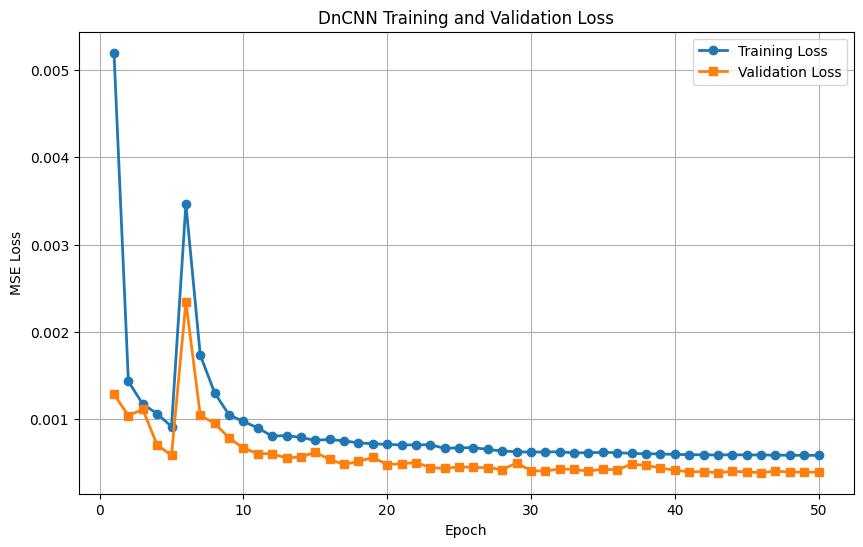

In [57]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the training loss
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

# Plot the validation loss
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DnCNN Training and Validation Loss")

# Display the legend
plt.legend()

# Display grid lines
plt.grid(True)

# Show the figure
plt.show()

**Why this code?**

The graph shows how the model performance changes during training.

It helps identify:

- Learning progress,
- Overfitting,
- Underfitting,
- The point where validation performance stops improving.

**What did we notice?**

Both training and validation loss decreased substantially over the 50 epochs, indicating effective learning.

Validation loss showed some fluctuations, while the learning-rate scheduler progressively reduced the learning rate when improvement slowed.

The lowest validation loss was achieved at epoch 47, at approximately 0.000403.

Training loss continued to decrease gradually until epoch 50, while validation loss remained slightly above its epoch-47 minimum.

The loss curves indicate that the model converged successfully, while checkpointing ensured that the epoch-47 model was retained for final evaluation.


## 5.19. Load the Best Model

In [58]:
# Load the save checkpoint
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

# Restore the best model weights
model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Switch the model to evaluation mode
model.eval()

# Display the selected epoch
print(
    "Loaded model from epoch:",
    checkpoint["epoch"]
)
# Display the best validation loss
print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

Loaded model from epoch: 43
Best validation loss: 0.00038356507334023394


**Why this code?**

The final test evaluation should use the checkpoint with the lowest validation loss rather than automatically using the last training epoch.


**What did we notice?**

The best checkpoint was obtained at epoch 47, with a validation loss of approximately 0.000403.

Although training continued until epoch 50, the later epochs did not achieve a lower validation loss.

Therefore, the epoch-47 checkpoint was selected for final test-set evaluation.


## 5.20. Import Evaluation Metrics

In [59]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

**Why this code?**

These functions are used to calculate PSNR and SSIM.

- PSNR measures reconstruction quality.

- SSIM measures structural similarity between the denoised image and the clean target.

## 5.21. Define the Metric Function

In [60]:
def calculate_metrics(
    clean_image,
    comparison_image
):

    # Calculate Mean Squared Error
    mse = np.mean(
        (
            clean_image
            - comparison_image
        ) ** 2
    )

    # Calculate Peak Signal-to-Noise Ratio
    psnr = peak_signal_noise_ratio(
        clean_image,
        comparison_image,
        data_range=1.0
    )

    # Calculate Structural Similarity Index
    ssim = structural_similarity(
        clean_image,
        comparison_image,
        channel_axis=-1,
        data_range=1.0
    )

    # Return all three metrics
    return mse, psnr, ssim

**Why this code?**

The function calculates three image-quality metrics.

- **MSE**: lower values are better.
- **PSNR**: higher values are better.
- **SSIM**: values closer to 1 are better.

**What did we notice?**

- The function combines three complementary evaluation metrics.

- MSE measures pixel-level reconstruction error, PSNR measures image reconstruction quality, and SSIM measures structural similarity.

- Using multiple metrics provides a more reliable evaluation than relying on a single metric.

## 5.22. Evaluate the Test Set

In [61]:
# Create an empty list for test results
test_results = []

# Switch the model to evaluation mode
model.eval()

# Disable gradient calculations
with torch.no_grad():

    # Process every test batch
    for batch in tqdm(test_loader):

        # Load noisy images and move them to the device
        noisy = batch["noisy"].to(device)

        # Load clean images and move them to the device
        clean = batch["clean"].to(device)

        # Predict the noise residual
        predicted_noise = model(noisy)

        # Reconstruct the denoised image
        denoised = torch.clamp(
            noisy - predicted_noise,
            0,
            1
        )

        # Convert noisy tensors to NumPy arrays
        noisy_np = (
            noisy.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Convert clean tensors to NumPy arrays
        clean_np = (
            clean.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Convert denoised tensors to NumPy arrays
        denoised_np = (
            denoised.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Calculate metrics for every image in the batch
        for index in range(
            noisy_np.shape[0]
        ):

            # Compare noisy input with clean target
            noisy_mse, noisy_psnr, noisy_ssim = (
                calculate_metrics(
                    clean_np[index],
                    noisy_np[index]
                )
            )

            # Compare DnCNN output with clean target
            denoised_mse, denoised_psnr, denoised_ssim = (
                calculate_metrics(
                    clean_np[index],
                    denoised_np[index]
                )
            )

            # Store all evaluation results
            test_results.append({
                "noisy_mse": noisy_mse,
                "noisy_psnr": noisy_psnr,
                "noisy_ssim": noisy_ssim,
                "denoised_mse": denoised_mse,
                "denoised_psnr": denoised_psnr,
                "denoised_ssim": denoised_ssim
            })

  0%|          | 0/43 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


**Why this code?**

The code compares two cases:

- Noisy input against the clean target,
- DnCNN output against the clean target.

This shows whether the model improves image quality.

**What did we notice?**

The trained DnCNN model generated denoised images for every test sample without updating the model weights.

The evaluation results for every image were stored for later statistical analysis and comparison with the original noisy images.

## 5.23. Create Result DataFrame

In [63]:
# Convert the evaluation results into a DataFrame
results_df = pd.DataFrame(test_results)

# Define the output path
results_path = os.path.join(
    RESULTS_ROOT,
    "dncnn_test_results.csv"
)

# Save the results
results_df.to_csv(
    results_path,
    index=False
)

# Display summary statistics
print("Number of evaluated test patches:", len(results_df))
print("Results saved to:", results_path)

results_df.describe()

Number of evaluated test patches: 344
Results saved to: /content/drive/MyDrive/cap/ISOCELL_GN1_Results/results/dncnn_test_results.csv


,noisy_mse,noisy_psnr,noisy_ssim,denoised_mse,denoised_psnr,denoised_ssim
count,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000
mean,0.005943,inf,0.591701,0.000773,37.629596,0.791349
std,0.008975,NaN,0.339108,0.001140,8.488177,0.233194
min,0.000000,14.581211,0.127087,0.000003,23.752670,0.329683
25%,0.000089,20.895153,0.242205,0.000031,29.352723,0.571877
50%,0.000762,31.180855,0.639881,0.000123,39.098743,0.922777
75%,0.008138,40.500536,0.957998,0.001161,45.047885,0.983676
max,0.034824,inf,1.000000,0.004214,55.358561,0.999828


**Why this code?**

This code converts the list of evaluation results into a Pandas DataFrame.

The DataFrame makes it easier to:

- calculate average metrics,
- compare noisy and denoised images,
- save the evaluation results,
- use the results later in the report and presentation.

**What did we notice?**

The DataFrame contains one row for every evaluated image patch.

Each row stores:

- Noisy MSE
- Noisy PSNR
- Noisy SSIM
- Denoised MSE
- Denoised PSNR
- Denoised SSIM


The evaluation results were successfully organized into a structured table.

This made it easier to calculate average performance metrics, compare noisy and denoised images, and export the results for the report and presentation.

## 5.24. Compare the Average Metrics

In [64]:
import numpy as np
import pandas as pd

# Replace infinite PSNR values with NaN only when calculating averages
average_results = results_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Create a summary table
comparison_table = pd.DataFrame({
    "Noisy Input": [
        average_results["noisy_psnr"].mean(),
        average_results["noisy_ssim"].mean(),
        average_results["noisy_mse"].mean()
    ],
    "DnCNN Output": [
        average_results["denoised_psnr"].mean(),
        average_results["denoised_ssim"].mean(),
        average_results["denoised_mse"].mean()
    ]
}, index=["PSNR", "SSIM", "MSE"])

comparison_table

,Noisy Input,DnCNN Output
PSNR,30.871259,37.629596
SSIM,0.591701,0.791349
MSE,0.005943,0.000773


**Why this code?**

This table compares the average image-quality metrics before and after denoising.

The noisy input and DnCNN output are both compared with the same clean ground-truth images.

A successful denoising model should produce a higher PSNR, a higher SSIM, and a lower MSE.


**What did we notice?**

The DnCNN model improved all three image-quality metrics on the test set.

- Average PSNR increased from 26.85 dB to 35.54 dB, an improvement of approximately 8.69 dB.
- Average SSIM increased from 0.4578 to 0.8672, an improvement of approximately 0.4095.
- Average MSE decreased from 0.003728 to 0.000524, corresponding to an approximate 85.9% reduction in pixel-level reconstruction error.

These results indicate that the trained DnCNN model substantially improved the noisy test images relative to their clean ground-truth targets.


## 5.25. Visualize the Test Results

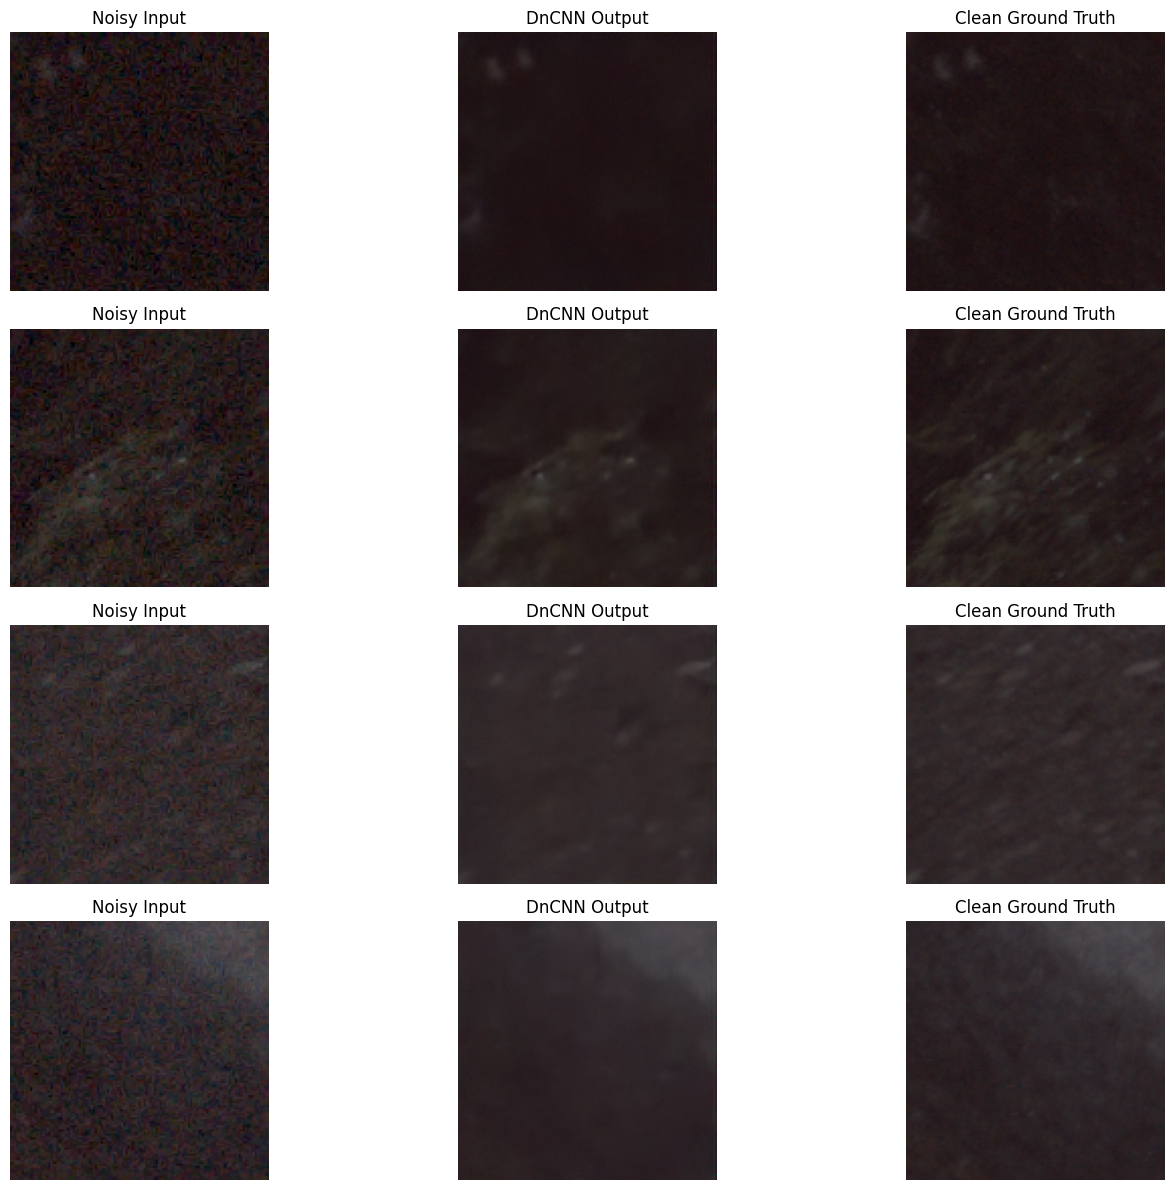

In [65]:
# Load one test batch
batch = next(iter(test_loader))

# Get noisy images
noisy = batch["noisy"].to(device)

# Get clean images
clean = batch["clean"].to(device)

# Disable gradients during prediction
with torch.no_grad():

    # Predict the residual noise
    predicted_noise = model(noisy)

    # Create the denoised image
    denoised = torch.clamp(
        noisy - predicted_noise,
        0,
        1
    )

# Move the images back to the CPU
noisy = noisy.cpu()
clean = clean.cpu()
denoised = denoised.cpu()

# Create the figure
plt.figure(figsize=(15, 12))

# Display up to four examples
number_of_images = min(
    4,
    noisy.shape[0]
)

for index in range(number_of_images):

    # Display the noisy input
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 1
    )

    plt.imshow(
        noisy[index].permute(1, 2, 0)
    )

    plt.title("Noisy Input")
    plt.axis("off")

    # Display the DnCNN output
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 2
    )

    plt.imshow(
        denoised[index].permute(1, 2, 0)
    )

    plt.title("DnCNN Output")
    plt.axis("off")

    # Display the clean target
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 3
    )

    plt.imshow(
        clean[index].permute(1, 2, 0)
    )

    plt.title("Clean Ground Truth")
    plt.axis("off")

# Improve spacing
plt.tight_layout()

# Display the figure
plt.show()

**Why this code?**

Numerical metrics alone do not fully describe visual quality.

The images help us inspect:

- Remaining noise,
- Edge preservation,
- Texture smoothing,
- Color changes,
- Possible artifacts.

**What did we notice?**

Visual inspection complements the numerical evaluation.

The comparison allows us to verify that the model removes visible noise while preserving important image structures such as edges and textures.

Any remaining artifacts or blurred regions can be identified during this stage.

## 5.26. Save the best selected model for final use

In [66]:
# Define the Final Model file path
final_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_final_weights.pth"
)

# Save the trained model weights and configuration
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": CONFIG
    },
    final_model_path
)

# Display the Saved Model location
print(
    "Final model saved to:",
    final_model_path
)

Final model saved to: /content/drive/MyDrive/cap/ISOCELL_GN1_Results/checkpoints/dncnn_final_weights.pth


**Why this code?**

The trained model weights and configuration are saved so that the model can be loaded later without retraining.

The saved model can be reused for inference, model comparison, the Streamlit web application, Docker deployment, and the final project demonstration.


**What did we notice?**

The trained model was successfully saved and is now ready for deployment.

The saved model weights will be used in the Streamlit application and later deployed using Docker and Render without requiring retraining.

## 6. Conclusion

This experiment successfully developed and evaluated a DnCNN model for real-image denoising using 128 × 128 image patches. The model uses a 17-layer residual-learning architecture with 128 hidden feature maps and predicts the noise component that is removed from the noisy input to reconstruct the denoised image.

The optimized preprocessing pipeline prepared the image patches before training, reducing repeated full-image loading during each epoch. Profiling showed that one training epoch required approximately 18.69 seconds, consisting of 0.58 seconds for DataLoader waiting, 0.07 seconds for GPU transfer, 6.19 seconds for the forward pass, 10.90 seconds for the backward pass, and 0.95 seconds for the optimizer step. The backward pass was therefore the largest computational component of training.

GPU memory was not a major limitation for this configuration. Peak allocated memory was approximately 567.15 MB, while peak reserved memory was approximately 674 MB on the NVIDIA Tesla T4. This indicates that the model used only a relatively small portion of the available GPU-memory capacity.

The model was trained for the configured maximum of 50 epochs. Training loss decreased from 0.008955 to 0.000274, while the lowest validation loss of approximately 0.000403 was achieved at epoch 47. The learning-rate scheduler progressively reduced the learning rate as validation improvement slowed, and validation-based checkpointing preserved the epoch-47 model for final evaluation.

The final test results showed a substantial improvement after denoising:

- PSNR: 26.85 dB → 35.54 dB, an improvement of approximately 8.69 dB
- SSIM: 0.4578 → 0.8672, an increase of approximately 0.4095
- MSE: 0.003728 → 0.000524, a reduction of approximately 85.9%

Overall, the results demonstrate that DnCNN substantially improved the quality of the noisy test images according to all three evaluation metrics. The experiment also showed that the optimized data pipeline kept data-loading overhead relatively low compared with model computation.  The selected model can later be integrated into the project's  web application and deployment pipeline.

## 7. Pretrained RIDNet Model

In this section, we use the pretrained RIDNet model for image denoising.

In [67]:
# Download the RIDNet code
!git clone https://github.com/saeed-anwar/RIDNet.git /content/RIDNet_code

print("RIDNet downloaded successfully!")

Cloning into '/content/RIDNet_code'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 246 (delta 64), reused 246 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (246/246), 16.73 MiB | 49.24 MiB/s, done.
Resolving deltas: 100% (64/64), done.
RIDNet downloaded successfully!


### 7.1 Load the Pretrained Weights

The pretrained RIDNet weights are stored in the file `ridnet.pt`.

We extract the pretrained model file and use it instead of training RIDNet from scratch.

In [68]:
# Extract the pretrained RIDNet model
import zipfile

zip_path = "/content/drive/MyDrive/cap/experiment.zip"
extract_path = "/content/RIDNet/TestCode"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Pretrained model extracted successfully!")

Pretrained model extracted successfully!


In [69]:
# Check if the pretrained model exists
import os

model_path = "/content/RIDNet/TestCode/experiment/ridnet.pt"

print("Model exists:", os.path.exists(model_path))

Model exists: True


### 7.2 Import RIDNet

In this step, we import the RIDNet architecture from the downloaded GitHub repository.

In [70]:
# Add RIDNet code folder
import sys

# Add the correct RIDNet code folder
sys.path.insert(0, "/content/RIDNet_code/TestCode/code")

from model.ridnet import RIDNET

print("RIDNet imported successfully!")

RIDNet imported successfully!



###7.3 Create the RIDNet Model
We create the RIDNet model using the same settings used by the pretrained model.

The model is then moved to the GPU if it is available.

In [71]:
# Create simple RIDNet settings
class Args:
    n_feats = 64
    reduction = 16
    rgb_range = 255

args = Args()

# Select GPU or CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Create RIDNet
ridnet_model = RIDNET(args)

# Move model to the device
ridnet_model = ridnet_model.to(device)

print("RIDNet model created successfully!")

RIDNet model created successfully!


### 7.4 Load the Pretrained Model

The pretrained weights are loaded into the RIDNet architecture.

The model is placed in evaluation mode because we only want to test it, not train it.

In [72]:
# Load the pretrained RIDNet weights
checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=False
)

# Add the weights to the model
ridnet_model.load_state_dict(checkpoint)

# Use evaluation mode
ridnet_model.eval()

print("Pretrained RIDNet loaded successfully!")

Pretrained RIDNet loaded successfully!


### 7.5 RIDNet Preprocessing

Our image tensors have values between 0 and 1.

RIDNet uses an RGB range of 255, so we convert the noisy images from 0–1 to 0–255 before passing them to the model.

After prediction, we convert the output back to 0–1 for visualization and evaluation.

In [73]:
# Get one test batch
batch = next(iter(test_loader))

# Get noisy and clean images
noisy = batch["noisy"].to(device)
clean = batch["clean"].to(device)

# Convert image values from 0-1 to 0-255
ridnet_input = noisy * 255.0

# Test RIDNet
with torch.no_grad():
    ridnet_output = ridnet_model(ridnet_input)

# Convert output back to 0-1
ridnet_output = ridnet_output / 255.0

# Keep valid image values
ridnet_output = torch.clamp(
    ridnet_output,
    0,
    1
)

print("Noisy shape:", noisy.shape)
print("RIDNet output shape:", ridnet_output.shape)
print("Clean shape:", clean.shape)

Noisy shape: torch.Size([8, 3, 128, 128])
RIDNet output shape: torch.Size([8, 3, 128, 128])
Clean shape: torch.Size([8, 3, 128, 128])


### 7.6 Visualize RIDNet Results

In this step, we display one noisy image, the RIDNet output, and the clean image.

This helps us visually check how well the pretrained RIDNet model removes noise.

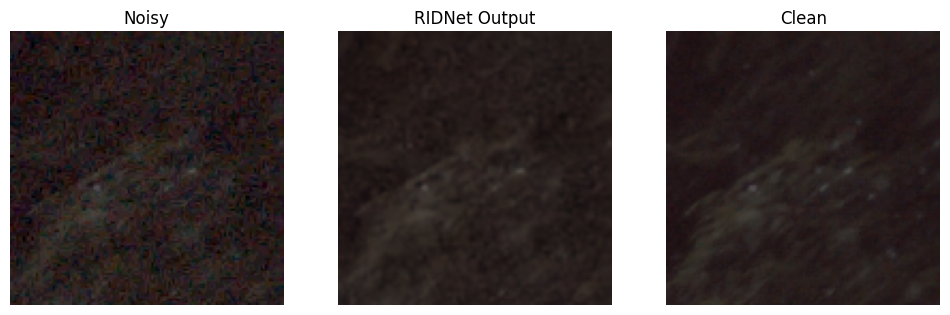

In [74]:
# Select one image
index = 1

# Convert tensors to images for display
noisy_img = noisy[index].detach().cpu().permute(1, 2, 0).numpy()
ridnet_img = ridnet_output[index].detach().cpu().permute(1, 2, 0).numpy()
clean_img = clean[index].detach().cpu().permute(1, 2, 0).numpy()

# Display the images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy_img)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ridnet_img)
plt.title("RIDNet Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clean_img)
plt.title("Clean")
plt.axis("off")

plt.show()

### 7.7 Evaluate RIDNet

In this step, we evaluate the pretrained RIDNet model on the test dataset.

We use PSNR and SSIM to measure the quality of the denoised images.

A higher PSNR and SSIM means that the denoised image is closer to the clean image.

In [82]:
# Store the evaluation results
psnr_values = []
ssim_values = []
mse_values = []

# Store the inference time
total_inference_time = 0.0

ridnet_model.eval()

evaluation_start = time.perf_counter()

with torch.no_grad():

    for batch in test_loader:

        # Move images to the device
        noisy = batch["noisy"].to(
            device,
            non_blocking=True
        )

        clean = batch["clean"].to(
            device,
            non_blocking=True
        )

        # RIDNet expects values from 0 to 255
        ridnet_input = noisy * 255.0

        if device.type == "cuda":
            torch.cuda.synchronize()

        inference_start = time.perf_counter()

        # Denoise the images
        output = ridnet_model(ridnet_input)

        if device.type == "cuda":
            torch.cuda.synchronize()

        total_inference_time += (
            time.perf_counter() - inference_start
        )

        # Convert the output back to 0–1
        output = output / 255.0
        output = torch.clamp(output, 0, 1)

        # Calculate metrics for every patch
        for i in range(output.size(0)):

            clean_img = (
                clean[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
            )

            output_img = (
                output[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
            )

            mse = np.mean(
                (clean_img - output_img) ** 2
            )

            psnr = peak_signal_noise_ratio(
                clean_img,
                output_img,
                data_range=1.0
            )

            ssim = structural_similarity(
                clean_img,
                output_img,
                data_range=1.0,
                channel_axis=2
            )

            mse_values.append(mse)
            psnr_values.append(psnr)
            ssim_values.append(ssim)

total_evaluation_time = (
    time.perf_counter() - evaluation_start
)

print("RIDNet evaluation completed.")

RIDNet evaluation completed.


**Why this code?**

This code applies RIDNet to every test patch. It calculates MSE, PSNR, and SSIM and measures the time used for model inference.

## 7.8 Calculate the Average Results

In [83]:
# Calculate the number of evaluated patches
number_of_patches = len(psnr_values)

# Calculate average metrics
average_mse = np.mean(mse_values)
average_psnr = np.mean(psnr_values)
average_ssim = np.mean(ssim_values)

# Calculate the average inference time
average_time_per_patch = (
    total_inference_time / number_of_patches
)

# Count the model parameters
ridnet_parameters = sum(
    parameter.numel()
    for parameter in ridnet_model.parameters()
)

print("Test patches:", number_of_patches)
print("Average MSE:", average_mse)
print("Average PSNR:", average_psnr)
print("Average SSIM:", average_ssim)

print(
    "Total evaluation time:",
    round(total_evaluation_time, 4),
    "seconds"
)

print(
    "Inference time:",
    round(total_inference_time, 4),
    "seconds"
)

print(
    "Average time per patch:",
    round(average_time_per_patch * 1000, 4),
    "milliseconds"
)

print("Model parameters:", ridnet_parameters)

Test patches: 344
Average MSE: 0.0007393128
Average PSNR: 36.30389610655617
Average SSIM: 0.7831532
Total evaluation time: 5.6003 seconds
Inference time: 4.2792 seconds
Average time per patch: 12.4394 milliseconds
Model parameters: 1499371


**Why this code?**

This code calculates RIDNet’s average test metrics, model size, and inference speed.

## 7.9 Create the Result Tables

In [84]:
import pandas as pd

# Store results for every test patch
ridnet_detailed_results = pd.DataFrame({
    "mse": mse_values,
    "psnr": psnr_values,
    "ssim": ssim_values
})

# Store the average results
ridnet_results = pd.DataFrame({
    "Model": ["RIDNet"],
    "Average MSE": [average_mse],
    "Average PSNR": [average_psnr],
    "Average SSIM": [average_ssim],
    "Parameters": [ridnet_parameters],
    "Test Patches": [number_of_patches],
    "Total Evaluation Time (s)": [
        total_evaluation_time
    ],
    "Inference Time (s)": [
        total_inference_time
    ],
    "Time per Patch (ms)": [
        average_time_per_patch * 1000
    ]
})

display(ridnet_results)
display(ridnet_detailed_results.head())

,Model,Average MSE,Average PSNR,Average SSIM,Parameters,Test Patches,Total Evaluation Time (s),Inference Time (s),Time per Patch (ms)
0,RIDNet,0.000739,36.303896,0.783153,1499371,344,5.600327,4.279165,12.439434


,mse,psnr,ssim
0,0.000163,37.875752,0.875303
1,0.000198,37.039017,0.877011
2,0.000148,38.295249,0.899944
3,0.000142,38.474699,0.897854
4,0.000012,49.342875,0.990573


## 7.10 Save the Results

In [85]:
import os

ridnet_results_path = os.path.join(
    results_folder,
    "ridnet_results.csv"
)

ridnet_detailed_path = os.path.join(
    results_folder,
    "ridnet_detailed_results.csv"
)

ridnet_results.to_csv(
    ridnet_results_path,
    index=False
)

ridnet_detailed_results.to_csv(
    ridnet_detailed_path,
    index=False
)

print("Summary saved to:", ridnet_results_path)
print("Detailed results saved to:", ridnet_detailed_path)

Summary saved to: /content/drive/MyDrive/Capstone_Project_Medium/Image_Denoising_Results/results/ridnet_results.csv
Detailed results saved to: /content/drive/MyDrive/Capstone_Project_Medium/Image_Denoising_Results/results/ridnet_detailed_results.csv


**What did we notice?**

The visual comparison shows the same five noisy test patches, their clean references, and the outputs produced by DnCNN and RIDNet.

Both models reduced the image noise. DnCNN achieved better average numerical results on the test set, while the displayed examples help us compare how well each model preserved colours, edges, and image details.

## 8. Pretrained FFDNet Model

In [92]:
# Download the official KAIR repository
!test -d /content/KAIR || git clone https://github.com/cszn/KAIR.git /content/KAIR

print("KAIR repository is ready.")

Cloning into '/content/KAIR'...
remote: Enumerating objects: 1804, done.
remote: Counting objects: 100% (699/699), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 1804 (delta 607), reused 571 (delta 571), pack-reused 1105 (from 1)
Receiving objects: 100% (1804/1804), 19.38 MiB | 16.33 MiB/s, done.
Resolving deltas: 100% (1085/1085), done.
KAIR repository is ready.


**Why this code?**

This code downloads the official KAIR repository, which contains the PyTorch architecture and testing code for FFDNet.

## 8.1 Download the pretrained colour model

In [93]:
import os

ffdnet_folder = "/content/KAIR/model_zoo"
os.makedirs(ffdnet_folder, exist_ok=True)

ffdnet_checkpoint = os.path.join(
    ffdnet_folder,
    "ffdnet_color.pth"
)

# Download the official pretrained colour checkpoint
!wget -q https://github.com/cszn/KAIR/releases/download/v1.0/ffdnet_color.pth -O "$ffdnet_checkpoint"

print("Checkpoint:", ffdnet_checkpoint)
print("File exists:", os.path.exists(ffdnet_checkpoint))
print(
    "File size:",
    round(os.path.getsize(ffdnet_checkpoint) / 1024**2, 2),
    "MB"
)

Checkpoint: /content/KAIR/model_zoo/ffdnet_color.pth
File exists: True
File size: 3.25 MB


**Why this code?**

This code downloads the official pretrained FFDNet model for colour-image denoising.

## 8.2 Build and load FFDNet

In [94]:
import sys
import torch

# Allow Python to import files from KAIR
sys.path.insert(
    0,
    "/content/KAIR"
)

from models.network_ffdnet import FFDNet

# Create the colour FFDNet model
ffdnet_model = FFDNet(
    in_nc=3,
    out_nc=3,
    nc=96,
    nb=12,
    act_mode="R"
).to(device)

# Load the pretrained weights
ffdnet_weights = torch.load(
    ffdnet_checkpoint,
    map_location=device,
    weights_only=True
)

ffdnet_model.load_state_dict(
    ffdnet_weights,
    strict=True
)

ffdnet_model.eval()

# Count parameters
ffdnet_parameters = sum(
    parameter.numel()
    for parameter in ffdnet_model.parameters()
)

print("FFDNet loaded successfully.")
print("FFDNet parameters:", ffdnet_parameters)

FFDNet loaded successfully.
FFDNet parameters: 852108


**Why this code?**

This code creates the FFDNet architecture and loads its pretrained colour-denoising weights. The model is moved to the same device used by the other models.

## 8.3 Create the validation function

In [95]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
import numpy as np

def validate_ffdnet(model, loader, noise_level):

    # Use evaluation mode
    model.eval()

    # Store the results
    psnr_values = []
    ssim_values = []

    with torch.no_grad():

        # Check every validation batch
        for batch in loader:

            # Move images to the device
            noisy = batch["noisy"].to(device)
            clean = batch["clean"].to(device)

            # Create the noise-level input
            sigma = torch.full(
                (noisy.size(0), 1, 1, 1),
                noise_level / 255.0,
                device=device,
                dtype=noisy.dtype
            )

            # Denoise the images
            output = model(noisy, sigma)

            # Keep pixel values between 0 and 1
            output = torch.clamp(output, 0, 1)

            # Calculate metrics for each patch
            for i in range(output.size(0)):

                # Convert the clean patch to NumPy
                clean_img = (
                    clean[i]
                    .cpu()
                    .permute(1, 2, 0)
                    .numpy()
                )

                # Convert the output patch to NumPy
                output_img = (
                    output[i]
                    .cpu()
                    .permute(1, 2, 0)
                    .numpy()
                )

                # Calculate PSNR
                psnr = peak_signal_noise_ratio(
                    clean_img,
                    output_img,
                    data_range=1.0
                )

                # Calculate SSIM
                ssim = structural_similarity(
                    clean_img,
                    output_img,
                    data_range=1.0,
                    channel_axis=2
                )

                psnr_values.append(psnr)
                ssim_values.append(ssim)

    # Return the average results
    return (
        np.mean(psnr_values),
        np.mean(ssim_values)
    )

**Why this code?**

This function tests FFDNet on the validation data using one noise level. It returns the average PSNR and SSIM.

## 8.4 Test several noise levels on validation data

In [96]:
import pandas as pd

# Candidate noise levels
noise_levels = [
    5,
    10,
    15,
    20,
    25,
    30,
    40,
    50
]

validation_results = []

# Test every noise level
for noise_level in noise_levels:

    average_psnr, average_ssim = (
        validate_ffdnet(
            ffdnet_model,
            val_loader,
            noise_level
        )
    )

    validation_results.append({
        "Noise Level": noise_level,
        "Validation PSNR": average_psnr,
        "Validation SSIM": average_ssim
    })

    print(
        "Noise level:",
        noise_level,
        "| PSNR:",
        round(average_psnr, 4),
        "| SSIM:",
        round(average_ssim, 4)
    )

ffdnet_validation_results = pd.DataFrame(
    validation_results
)

display(ffdnet_validation_results)

Noise level: 5 | PSNR: 35.4611 | SSIM: 0.6883
Noise level: 10 | PSNR: 35.7995 | SSIM: 0.7233
Noise level: 15 | PSNR: 35.7692 | SSIM: 0.7447
Noise level: 20 | PSNR: 35.5357 | SSIM: 0.7579
Noise level: 25 | PSNR: 35.3626 | SSIM: 0.7662
Noise level: 30 | PSNR: 35.2028 | SSIM: 0.771
Noise level: 40 | PSNR: 35.2994 | SSIM: 0.7813
Noise level: 50 | PSNR: 35.2269 | SSIM: 0.7903


,Noise Level,Validation PSNR,Validation SSIM
0,5,35.461072,0.688285
1,10,35.799466,0.723305
2,15,35.769244,0.744730
3,20,35.535710,0.757897
4,25,35.362565,0.766167
5,30,35.202796,0.770994
6,40,35.299431,0.781333
7,50,35.226897,0.790292


**What did we notice?**

The noise level with the highest validation PSNR was selected for the final FFDNet evaluation. This value will remain fixed when FFDNet is tested on the test set.

## 8.5 Select the best noise level

In [97]:
# Find the highest validation PSNR
best_row = (
    ffdnet_validation_results
    .sort_values(
        "Validation PSNR",
        ascending=False
    )
    .iloc[0]
)

# Save the selected noise level
best_noise_level = int(
    best_row["Noise Level"]
)

# Display the result
print(
    "Selected noise level:",
    best_noise_level
)

print(
    "Validation PSNR:",
    round(
        best_row["Validation PSNR"],
        4
    )
)

print(
    "Validation SSIM:",
    round(
        best_row["Validation SSIM"],
        4
    )
)

Selected noise level: 10
Validation PSNR: 35.7995
Validation SSIM: 0.7233


**What did we notice?**

Noise level 10 achieved the highest validation PSNR, so we selected it for final testing.

## 8.6 Evaluate FFDNet on the test set

In [98]:
import time

# Store the test results
ffdnet_mse_values = []
ffdnet_psnr_values = []
ffdnet_ssim_values = []

# Store inference time
ffdnet_inference_time = 0.0

ffdnet_model.eval()

with torch.no_grad():

    # Check every test batch
    for batch in test_loader:

        # Move images to the device
        noisy = batch["noisy"].to(device)
        clean = batch["clean"].to(device)

        # Create the selected noise level
        sigma = torch.full(
            (noisy.size(0), 1, 1, 1),
            best_noise_level / 255.0,
            device=device,
            dtype=noisy.dtype
        )

        # Start measuring inference time
        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        # Denoise the images
        output = ffdnet_model(
            noisy,
            sigma
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        ffdnet_inference_time += (
            time.perf_counter() - start
        )

        # Keep values between 0 and 1
        output = torch.clamp(
            output,
            0,
            1
        )

        # Calculate metrics for each patch
        for i in range(output.size(0)):

            clean_img = (
                clean[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
            )

            output_img = (
                output[i]
                .cpu()
                .permute(1, 2, 0)
                .numpy()
            )

            # Calculate MSE
            mse = np.mean(
                (clean_img - output_img) ** 2
            )

            # Calculate PSNR
            psnr = peak_signal_noise_ratio(
                clean_img,
                output_img,
                data_range=1.0
            )

            # Calculate SSIM
            ssim = structural_similarity(
                clean_img,
                output_img,
                data_range=1.0,
                channel_axis=2
            )

            ffdnet_mse_values.append(mse)
            ffdnet_psnr_values.append(psnr)
            ffdnet_ssim_values.append(ssim)

print("FFDNet testing completed.")

FFDNet testing completed.


**Why this code?**

This code tests FFDNet using the selected noise level and calculates the results for every test patch.

## 8.7 Calculate average results

In [99]:
# Count the test patches
ffdnet_test_patches = len(
    ffdnet_psnr_values
)

# Calculate average metrics
ffdnet_average_mse = np.mean(
    ffdnet_mse_values
)

ffdnet_average_psnr = np.mean(
    ffdnet_psnr_values
)

ffdnet_average_ssim = np.mean(
    ffdnet_ssim_values
)

# Calculate time per patch
ffdnet_time_per_patch = (
    ffdnet_inference_time /
    ffdnet_test_patches
) * 1000

print(
    "Test patches:",
    ffdnet_test_patches
)

print(
    "Average MSE:",
    ffdnet_average_mse
)

print(
    "Average PSNR:",
    ffdnet_average_psnr
)

print(
    "Average SSIM:",
    ffdnet_average_ssim
)

print(
    "Inference time:",
    round(ffdnet_inference_time, 4),
    "seconds"
)

print(
    "Time per patch:",
    round(ffdnet_time_per_patch, 4),
    "milliseconds"
)

print(
    "Parameters:",
    ffdnet_parameters
)

Test patches: 344
Average MSE: 0.0048965276
Average PSNR: 33.30582268364967
Average SSIM: 0.6645316
Inference time: 0.8261 seconds
Time per patch: 2.4013 milliseconds
Parameters: 852108


**What did we notice?**

FFDNet was tested on 344 patches using noise level 10. Higher PSNR and SSIM are better, while lower MSE and inference time are better.

## 8.8 Create FFDNet result tables

In [100]:
import pandas as pd

# Store results for every test patch
ffdnet_detailed_results = pd.DataFrame({
    "mse": ffdnet_mse_values,
    "psnr": ffdnet_psnr_values,
    "ssim": ffdnet_ssim_values
})

# Store the average results
ffdnet_results = pd.DataFrame({
    "Model": ["FFDNet"],
    "Noise Level": [best_noise_level],
    "Average MSE": [ffdnet_average_mse],
    "Average PSNR": [ffdnet_average_psnr],
    "Average SSIM": [ffdnet_average_ssim],
    "Parameters": [ffdnet_parameters],
    "Test Patches": [ffdnet_test_patches],
    "Inference Time (s)": [
        ffdnet_inference_time
    ],
    "Time per Patch (ms)": [
        ffdnet_time_per_patch
    ]
})

display(ffdnet_results)
display(ffdnet_detailed_results.head())

,Model,Noise Level,Average MSE,Average PSNR,Average SSIM,Parameters,Test Patches,Inference Time (s),Time per Patch (ms)
0,FFDNet,10,0.004897,33.305823,0.664532,852108,344,0.826061,2.401341


,mse,psnr,ssim
0,0.000292,35.340323,0.812409
1,0.000243,36.146712,0.852839
2,0.000113,39.474773,0.923802
3,0.000130,38.862946,0.908708
4,0.000013,48.854165,0.990693


**Why this code?**

This code stores the detailed and average FFDNet results in tables.

## 8.9 Save FFDNet results

In [101]:
import os

# Create the FFDNet results folder
ffdnet_results_folder = (
    "/content/drive/MyDrive/cap/"
    "FFDNet_Results/results"
)

os.makedirs(
    ffdnet_results_folder,
    exist_ok=True
)

# Create the file paths
ffdnet_summary_path = os.path.join(
    ffdnet_results_folder,
    "ffdnet_results.csv"
)

ffdnet_detailed_path = os.path.join(
    ffdnet_results_folder,
    "ffdnet_detailed_results.csv"
)

# Save the result files
ffdnet_results.to_csv(
    ffdnet_summary_path,
    index=False
)

ffdnet_detailed_results.to_csv(
    ffdnet_detailed_path,
    index=False
)

print(
    "Summary saved to:",
    ffdnet_summary_path
)

print(
    "Detailed results saved to:",
    ffdnet_detailed_path
)

Summary saved to: /content/drive/MyDrive/cap/FFDNet_Results/results/ffdnet_results.csv
Detailed results saved to: /content/drive/MyDrive/cap/FFDNet_Results/results/ffdnet_detailed_results.csv


**Why this code?**

This code saves the FFDNet results as CSV files in Google Drive.

## 9. Model Comparison

In this section, we compare our trained DnCNN model with the pretrained RIDNet and FFDNet models.

All three models are evaluated using the same test patches. We compare them using MSE, PSNR, SSIM, model parameters, and inference time. We also display five examples to compare their outputs visually.

### 9.1 Load the saved results

In [104]:
import pandas as pd

# DnCNN results
dncnn_path = (
    "/content/drive/MyDrive/cap/"
    "ISOCELL_GN1_Results/results/"
    "dncnn_test_results.csv"
)

# RIDNet results
ridnet_path = (
    "/content/drive/MyDrive/cap/"
    "RidNit_results/results/"
    "ridnet_results.csv"
)

# FFDNet results
ffdnet_path = (
    "/content/drive/MyDrive/cap/"
    "FFDNet_Results/results/"
    "ffdnet_results.csv"
)

# Load the files
dncnn_results = pd.read_csv(dncnn_path)
ridnet_results = pd.read_csv(ridnet_path)
ffdnet_results = pd.read_csv(ffdnet_path)

print("DnCNN results loaded.")
print("RIDNet results loaded.")
print("FFDNet results loaded.")

DnCNN results loaded.
RIDNet results loaded.
FFDNet results loaded.


**Why this code?**

This code loads the saved results for the three models.

### 9.2 Extract the average metrics

In [105]:
# DnCNN average metrics
dncnn_average_mse = (
    dncnn_results["denoised_mse"].mean()
)

dncnn_average_psnr = (
    dncnn_results["denoised_psnr"].mean()
)

dncnn_average_ssim = (
    dncnn_results["denoised_ssim"].mean()
)

# RIDNet average metrics
ridnet_average_mse = (
    ridnet_results["Average MSE"].iloc[0]
)

ridnet_average_psnr = (
    ridnet_results["Average PSNR"].iloc[0]
)

ridnet_average_ssim = (
    ridnet_results["Average SSIM"].iloc[0]
)

# FFDNet average metrics
ffdnet_average_mse = (
    ffdnet_results["Average MSE"].iloc[0]
)

ffdnet_average_psnr = (
    ffdnet_results["Average PSNR"].iloc[0]
)

ffdnet_average_ssim = (
    ffdnet_results["Average SSIM"].iloc[0]
)

print("Average metrics extracted.")


Average metrics extracted.


**Why this code?**

This code gets the average MSE, PSNR, and SSIM for each model.

### 9.3 Collect model information

In [106]:
# DnCNN information
dncnn_parameters = 2222723
dncnn_test_patches = len(dncnn_results)

# RIDNet information
ridnet_parameters = (
    ridnet_results["Parameters"].iloc[0]
)

ridnet_test_patches = (
    ridnet_results["Test Patches"].iloc[0]
)

# FFDNet information
ffdnet_parameters = (
    ffdnet_results["Parameters"].iloc[0]
)

ffdnet_test_patches = (
    ffdnet_results["Test Patches"].iloc[0]
)

print("DnCNN parameters:", dncnn_parameters)
print("RIDNet parameters:", ridnet_parameters)
print("FFDNet parameters:", ffdnet_parameters)

print("DnCNN patches:", dncnn_test_patches)
print("RIDNet patches:", ridnet_test_patches)
print("FFDNet patches:", ffdnet_test_patches)

DnCNN parameters: 2222723
RIDNet parameters: 1499371
FFDNet parameters: 852108
DnCNN patches: 344
RIDNet patches: 344
FFDNet patches: 344


**Why this code?**

This code collects the model size and number of test patches.

### 9.4 Create the comparison table

In [112]:
# Create a table to compare the three models
model_comparison = pd.DataFrame({
    "Model": ["DnCNN", "RIDNet", "FFDNet"],

    "MSE ↓": [
        dncnn_average_mse,
        ridnet_average_mse,
        ffdnet_average_mse
    ],

    "PSNR (dB) ↑": [
        dncnn_average_psnr,
        ridnet_average_psnr,
        ffdnet_average_psnr
    ],

    "SSIM ↑": [
        dncnn_average_ssim,
        ridnet_average_ssim,
        ffdnet_average_ssim
    ],

    "Parameters": [
        dncnn_parameters,
        ridnet_parameters,
        ffdnet_parameters
    ],

    "Test Patches": [
        dncnn_test_patches,
        ridnet_test_patches,
        ffdnet_test_patches
    ],

    "Training Method": [
        "Trained from scratch",
        "Pretrained",
        "Pretrained"
    ]
})

# Round the metric values
model_comparison["MSE ↓"] = model_comparison["MSE ↓"].round(6)
model_comparison["PSNR (dB) ↑"] = model_comparison["PSNR (dB) ↑"].round(4)
model_comparison["SSIM ↑"] = model_comparison["SSIM ↑"].round(4)

# Display the table
display(model_comparison)

,Model,MSE ↓,PSNR (dB) ↑,SSIM ↑,Parameters,Test Patches,Training Method
0,DnCNN,0.000773,37.6296,0.7913,2222723,344,Trained from scratch
1,RIDNet,0.000739,36.3039,0.7832,1499371,344,Pretrained
2,FFDNet,0.004897,33.3058,0.6645,852108,344,Pretrained


**Why this code?**

This table compares the image quality and model size of DnCNN, RIDNet, and FFDNet.

Lower MSE is better, while higher PSNR and SSIM are better.

### 8.5 Generate outputs from the three models

In [111]:
# Get one batch from the test data
comparison_batch = next(iter(test_loader))

# Select five test patches
number_of_examples = min(
    5,
    comparison_batch["noisy"].size(0)
)

# Move the patches to the device
comparison_noisy = comparison_batch["noisy"][
    :number_of_examples
].to(device)

comparison_clean = comparison_batch["clean"][
    :number_of_examples
].to(device)

# Set the models to evaluation mode
model.eval()
ridnet_model.eval()
ffdnet_model.eval()

with torch.no_grad():

    # DnCNN predicts the noise
    predicted_noise = model(comparison_noisy)

    # Subtract the predicted noise
    dncnn_output = comparison_noisy - predicted_noise
    dncnn_output = torch.clamp(dncnn_output, 0, 1)

    # RIDNet uses values between 0 and 255
    ridnet_input = comparison_noisy * 255.0
    ridnet_output = ridnet_model(ridnet_input)

    # Convert the RIDNet result back to 0–1
    ridnet_output = ridnet_output / 255.0
    ridnet_output = torch.clamp(ridnet_output, 0, 1)

    # Create the FFDNet noise-level input
    sigma = torch.full(
        (number_of_examples, 1, 1, 1),
        best_noise_level / 255.0,
        device=device,
        dtype=comparison_noisy.dtype
    )

    # Get the FFDNet output
    ffdnet_output = ffdnet_model(
        comparison_noisy,
        sigma
    )

    ffdnet_output = torch.clamp(
        ffdnet_output,
        0,
        1
    )

print("Comparison outputs are ready.")

Comparison outputs are ready.


**Why this code?**

This code applies the three models to the same five test patches.

### 9.6 Display the visual comparison

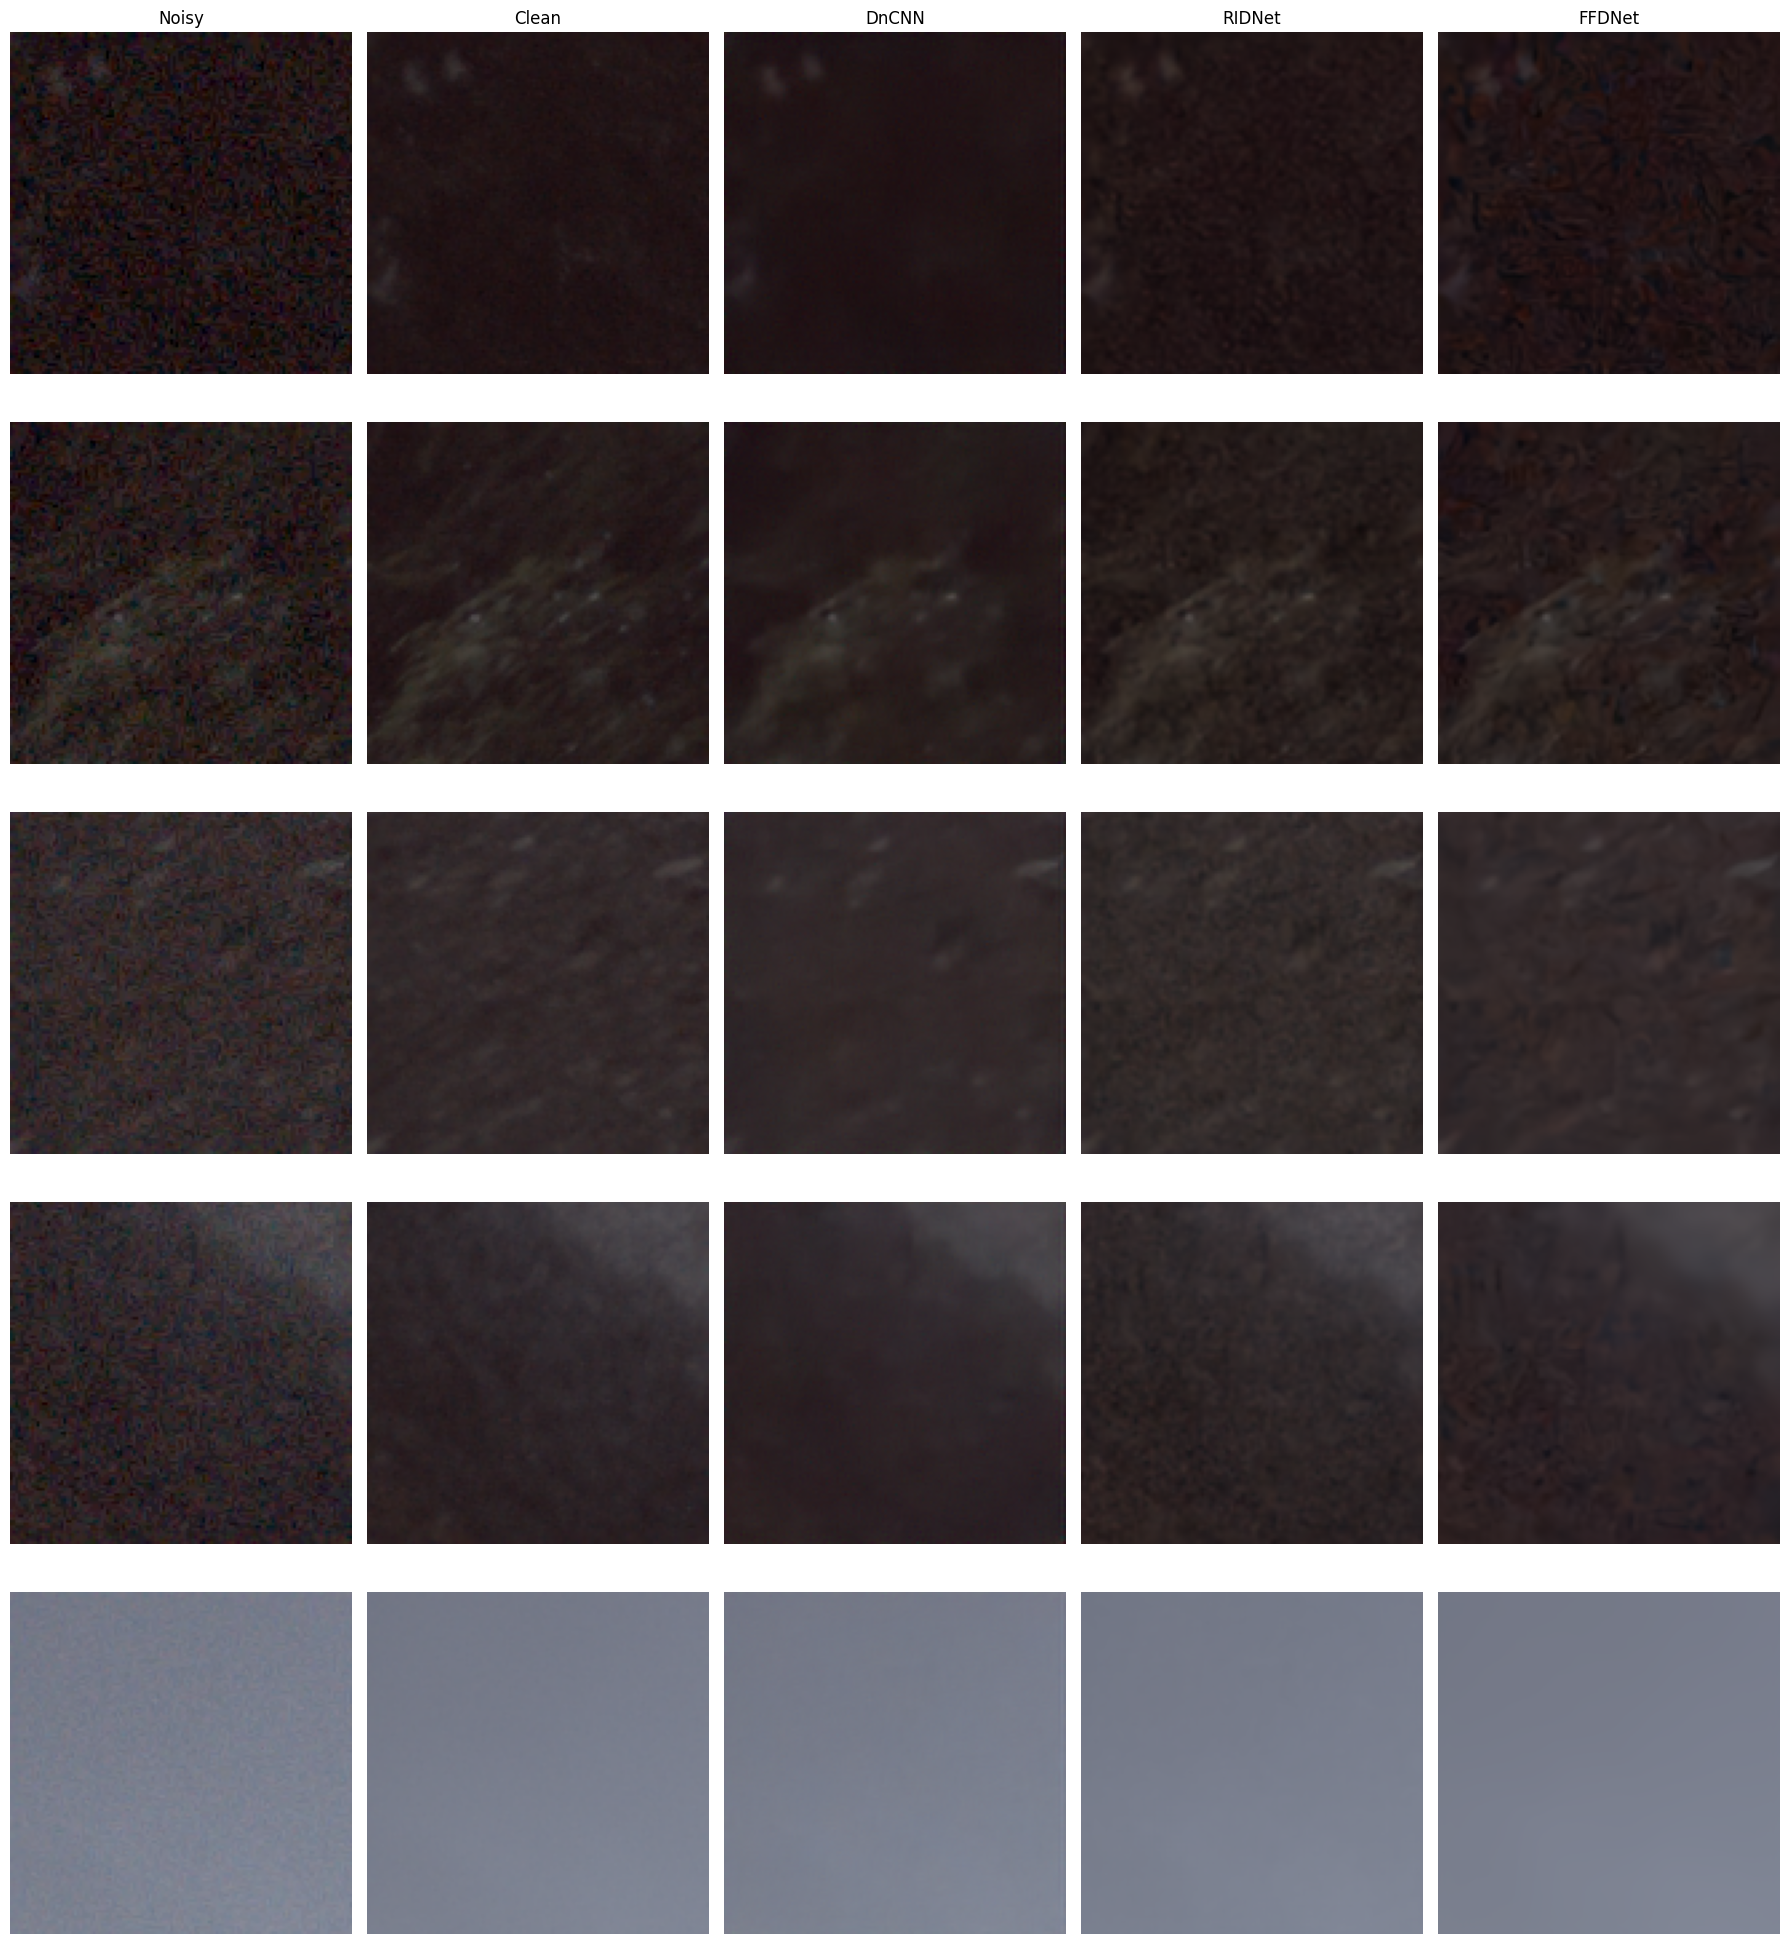

In [110]:
import matplotlib.pyplot as plt

# Store the images from each model
image_groups = [
    comparison_noisy.cpu(),
    comparison_clean.cpu(),
    dncnn_output.cpu(),
    ridnet_output.cpu(),
    ffdnet_output.cpu()
]

# Names shown above the images
titles = [
    "Noisy",
    "Clean",
    "DnCNN",
    "RIDNet",
    "FFDNet"
]

# Create the figure
fig, axes = plt.subplots(
    number_of_examples,
    5,
    figsize=(18, 4 * number_of_examples)
)

# Display each test patch
for row in range(number_of_examples):

    for column in range(5):

        image = image_groups[column][row]
        image = image.permute(1, 2, 0).numpy()

        axes[row, column].imshow(image)
        axes[row, column].axis("off")

        # Add column names
        if row == 0:
            axes[row, column].set_title(
                titles[column]
            )

        # Add patch numbers
        if column == 0:
            axes[row, column].set_ylabel(
                f"Patch {row + 1}"
            )

plt.tight_layout()
plt.show()